In [33]:
import sys
print(sys.version)
print(sys.executable)

3.12.14 (main, Aug 12 2026, 13:57:54) [Clang 21.0.0 (clang-2100.1.1.101)]
/Users/suryaanshs/repos/quantum-option-pricing-using-black-scholes-equation/.venv/bin/python


In [34]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from option_engine import EuropeanOption, OptionType
from qae_pricer import (
    QAEOptionPricer,
    classical_monte_carlo_price,
    convergence_comparison
)

print("Imports successful.")

Imports successful.


In [35]:
#setting option parameters: 
S0 = 100
K = 105
r = 0.05
sigma = 0.20
T = 40 / 365
q = 0.0

print("Option Parameters")
print("-----------------")
print(f"Spot Price       : {S0}")
print(f"Strike Price     : {K}")
print(f"Risk-Free Rate   : {r:.2%}")
print(f"Volatility       : {sigma:.2%}")
print(f"Time to Maturity : {T:.6f} years")
print(f"Dividend Yield   : {q:.2%}")

Option Parameters
-----------------
Spot Price       : 100
Strike Price     : 105
Risk-Free Rate   : 5.00%
Volatility       : 20.00%
Time to Maturity : 0.109589 years
Dividend Yield   : 0.00%


In [36]:
#black-scholes price 
option = EuropeanOption(
    S0=S0,
    K=K,
    r=r,
    sigma=sigma,
    T=T,
    q=q,
    option_type=OptionType.CALL
)

bs_price = option.price()
greeks = option.greeks()

print(f"Black-Scholes Call Price: {bs_price:.6f}")
print()
print("Greeks")
print("------")
print(f"Delta : {greeks.delta:.6f}")
print(f"Gamma : {greeks.gamma:.6f}")
print(f"Vega  : {greeks.vega:.6f}")
print(f"Theta : {greeks.theta:.6f}")
print(f"Rho   : {greeks.rho:.6f}")

Black-Scholes Call Price: 1.043668

Greeks
------
Delta : 0.267283
Gamma : 0.049687
Vega  : 10.890269
Theta : -11.221600
Rho   : 2.814749


In [37]:
#qae pricer
pricer = QAEOptionPricer(
    S0=S0,
    K=K,
    r=r,
    sigma=sigma,
    T=T,
    q=q,
    num_uncertainty_qubits=3
)

qae_result = pricer.price(epsilon_target=0.01)

print(f"QAE / IAE Price      : {qae_result.price:.6f}")
print(f"Oracle Queries       : {qae_result.oracle_queries}")
print(f"Uncertainty Qubits   : {qae_result.num_uncertainty_qubits}")
print(f"Target Epsilon       : {qae_result.epsilon_target}")

QAE / IAE Price      : 1.193320
Oracle Queries       : 7168
Uncertainty Qubits   : 3
Target Epsilon       : 0.01


In [38]:
#comparing the two
qae_price = qae_result.price
absolute_error = abs(qae_price - bs_price)
percentage_error = absolute_error / bs_price * 100

comparison = pd.Series({
    "Black-Scholes Price": bs_price,
    "QAE / IAE Price": qae_price,
    "Absolute Error": absolute_error,
    "Percentage Error": percentage_error,
    "Oracle Queries": qae_result.oracle_queries
})

comparison

Black-Scholes Price       1.043668
QAE / IAE Price           1.193320
Absolute Error            0.149653
Percentage Error         14.339113
Oracle Queries         7168.000000
dtype: float64

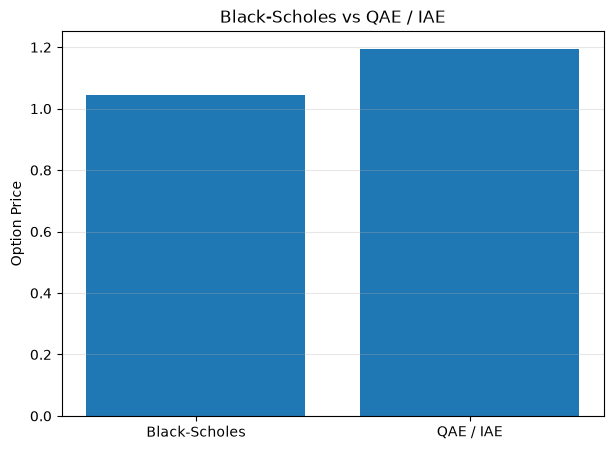

In [39]:
#comparison plot:
plt.figure(figsize=(7, 5))

plt.bar(
    ["Black-Scholes", "QAE / IAE"],
    [bs_price, qae_price]
)

plt.ylabel("Option Price")
plt.title("Black-Scholes vs QAE / IAE")
plt.grid(axis="y", alpha=0.3)

plt.show()

In [40]:
#classical monte carlo vs IAE
epsilon_targets = list(np.logspace(-1, -2, num=5))
sample_sizes = list(np.logspace(2, 6, num=10, dtype=int))

start = time.perf_counter()

df = convergence_comparison(
    S0=S0,
    K=K,
    r=r,
    sigma=sigma,
    T=T,
    epsilon_targets=epsilon_targets,
    sample_sizes=sample_sizes,
    num_uncertainty_qubits=3,
    seed=42
)

elapsed = time.perf_counter() - start

print(f"Benchmark completed in {elapsed:.2f} seconds.")
df

Benchmark completed in 0.64 seconds.


,method,queries,error
0,CMC,100,0.668819
1,CMC,278,0.139803
2,CMC,774,0.104852
3,CMC,2154,0.006751
4,CMC,5994,0.010460
5,CMC,16681,0.046733
6,CMC,46415,0.001016
7,CMC,129154,0.006195
8,CMC,359381,0.003701
9,CMC,1000000,0.001264


In [41]:
#seperating the two, CMC vs IAE: 
cmc = df[df["method"] == "CMC"].copy()
iae = df[df["method"] == "IAE"].copy()

print("Classical Monte Carlo")
display(cmc)

print("Iterative Amplitude Estimation")
display(iae)

Classical Monte Carlo


,method,queries,error
0,CMC,100,0.668819
1,CMC,278,0.139803
2,CMC,774,0.104852
3,CMC,2154,0.006751
4,CMC,5994,0.010460
5,CMC,16681,0.046733
6,CMC,46415,0.001016
7,CMC,129154,0.006195
8,CMC,359381,0.003701
9,CMC,1000000,0.001264


Iterative Amplitude Estimation


,method,queries,error
10,IAE,0,0.491995
11,IAE,0,0.891191
12,IAE,8192,0.241071
13,IAE,5120,0.147653
14,IAE,5120,0.079260


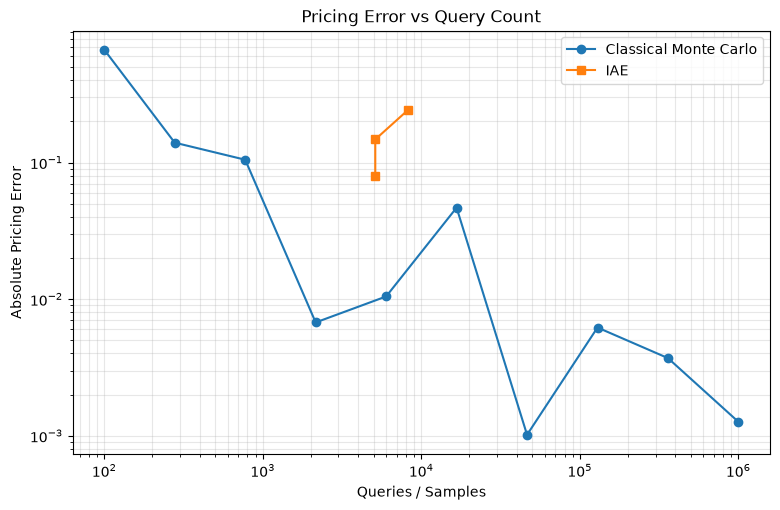

In [42]:
#primary convergence plot: 
plt.figure(figsize=(9, 5.5))

cmc_plot = cmc[cmc["queries"] > 0]
iae_plot = iae[iae["queries"] > 0]

plt.loglog(
    cmc_plot["queries"],
    cmc_plot["error"],
    "o-",
    label="Classical Monte Carlo"
)

plt.loglog(
    iae_plot["queries"],
    iae_plot["error"],
    "s-",
    label="IAE"
)

plt.xlabel("Queries / Samples")
plt.ylabel("Absolute Pricing Error")
plt.title("Pricing Error vs Query Count")
plt.legend()
plt.grid(True, which="both", alpha=0.3)

plt.show()

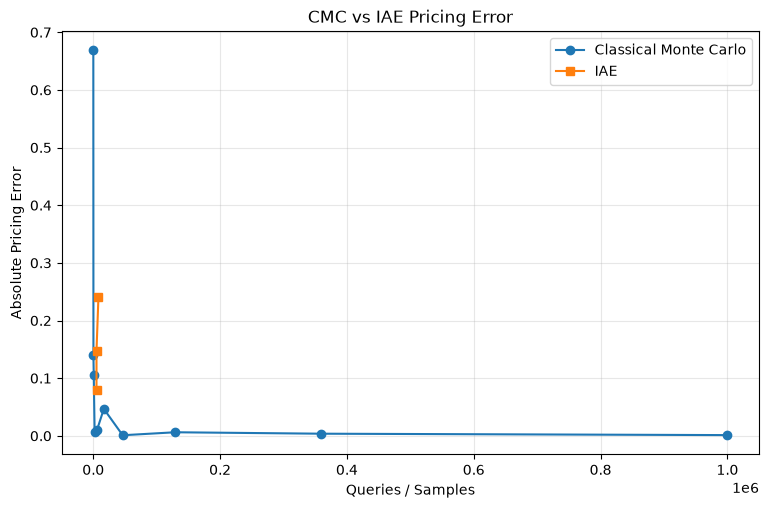

In [43]:
#simplified plot: 
plt.figure(figsize=(9, 5.5))

plt.plot(
    cmc_plot["queries"],
    cmc_plot["error"],
    "o-",
    label="Classical Monte Carlo"
)

plt.plot(
    iae_plot["queries"],
    iae_plot["error"],
    "s-",
    label="IAE"
)

plt.xlabel("Queries / Samples")
plt.ylabel("Absolute Pricing Error")
plt.title("CMC vs IAE Pricing Error")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

In [44]:
#additional: testing qubit sensitivity: 
qubit_results = []

for n_qubits in [3, 4, 5, 6]:
    test_pricer = QAEOptionPricer(
        S0=S0,
        K=K,
        r=r,
        sigma=sigma,
        T=T,
        q=q,
        num_uncertainty_qubits=n_qubits
    )

    result = test_pricer.price(epsilon_target=0.01)

    qubit_results.append({
        "qubits": n_qubits,
        "qae_price": result.price,
        "oracle_queries": result.oracle_queries,
        "absolute_error": abs(result.price - bs_price),
        "percentage_error": abs(result.price - bs_price) / bs_price * 100
    })

qubit_df = pd.DataFrame(qubit_results)
qubit_df

,qubits,qae_price,oracle_queries,absolute_error,percentage_error
0,3,1.132426,4096,0.088759,8.504502
1,4,1.233905,4096,0.190238,18.227799
2,5,1.164833,4096,0.121165,11.609569
3,6,1.229833,4096,0.186166,17.837642


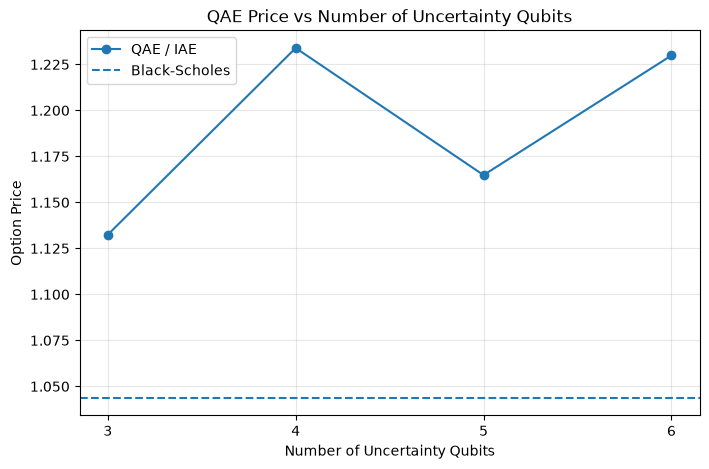

In [45]:
#plotting the same: 
plt.figure(figsize=(8, 5))

plt.plot(
    qubit_df["qubits"],
    qubit_df["qae_price"],
    "o-",
    label="QAE / IAE"
)

plt.axhline(
    bs_price,
    linestyle="--",
    label="Black-Scholes"
)

plt.xlabel("Number of Uncertainty Qubits")
plt.ylabel("Option Price")
plt.title("QAE Price vs Number of Uncertainty Qubits")
plt.xticks([3, 4, 5, 6])
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

In [57]:
#real world validation, fetching AAPL data
from real_world_validation import (
    fetch_price_history,
    fetch_risk_free_rate
)

history = fetch_price_history()
live_risk_free_rate = fetch_risk_free_rate()

print(f"Fetched {len(history)} trading days.")
print(f"Latest AAPL close: {history['Close'].iloc[-1]:.2f}")
print(f"Risk-free rate: {live_risk_free_rate:.4%}")

Fetched 127 trading days.
Latest AAPL close: 332.27
Risk-free rate: 3.9130%



Fetched 127 real trading days for AAPL (2026-03-12 to 2026-09-11)
Risk-free rate used: 3.9130%

0. LIVE SNAPSHOT (2026-09-11): pricing with real S0 and real trailing vol
Live spot S0:            332.27
Trailing 20-day realized vol: 23.75%
Strike K:                332
Time to maturity:        30 trading days (0.1190 yrs)

Analytical (Black-Scholes) price: 11.7601
Quantum (IAE, n=3) price:         12.9845  (6144 oracle queries)
Absolute disagreement:            1.2244  (10.41%)

1. GBM ASSUMPTION CHECK: are AAPL's real log-returns normal?
Daily log-return stdev:  0.01759  (annualized: 27.93%)
Skewness:                -0.818  (0.0 = symmetric, as GBM assumes)
Excess kurtosis:         +3.415  (0.0 = normal tails, as GBM assumes)
Jarque-Bera test:        stat=75.264, p-value=0.0000
  -> Rejects normality at 5% significance over this window.

2. WALK-FORWARD: analytical vs. quantum pricer on real daily market snapshots
Ran 107 real market snapshots (2026-04-10 to 2026-09-11)
Valid QAE days 

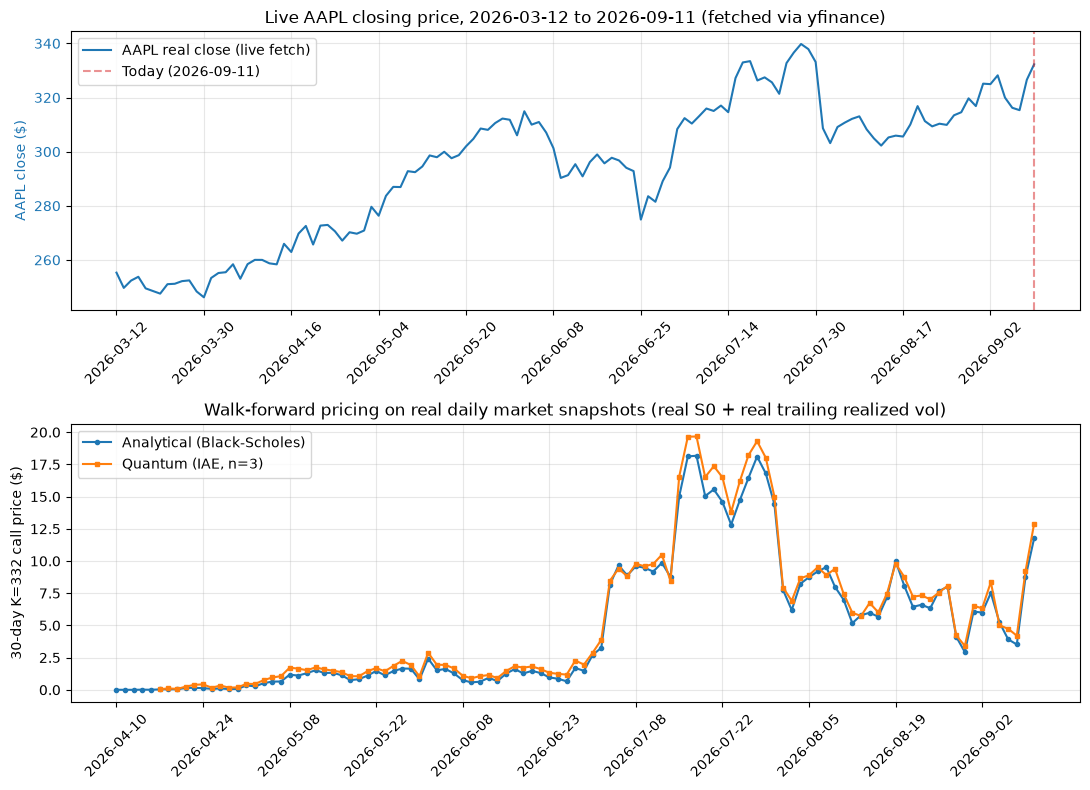

In [58]:
live_spot = history["Close"].iloc[-1]
K_live = round(live_spot)

run_validation(
    history,
    live_risk_free_rate,
    K_live,
    30
)